# Advanced Time Series Forecasting in Retail — Model Tournament
## M5 Forecasting | CA_1 Store | FOODS_3 Department | Top 10 Items
---
**Pipeline:** Data Loading → EDA → Phase 1 (Validation) → Phase 2 (Baselines) → Phase 3 (Univariate) → Phase 4 (Multivariate) → Phase 5 (Deep Learning + ML) → Phase 6 (Tournament)

In [1]:
# ============================================================
# CELL 0 — GLOBAL IMPORTS & UTILITIES
# ============================================================
import pandas as pd
import numpy as np
import warnings
import gc
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
SEED = 42
np.random.seed(SEED)

# ---------- Memory optimiser ----------
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'  Memory before: {start_mem:.2f} MB')
    for col in df.columns:
        col_type = df[col].dtype
        if pd.api.types.is_numeric_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type).startswith('int'):
                for dtype in [np.int8, np.int16, np.int32]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
            else:
                for dtype in [np.float16, np.float32]:
                    if c_min > np.finfo(dtype).min and c_max < np.finfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
        elif str(col_type) in ('object', 'string') and col != 'date':
            df[col] = df[col].astype('category')
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'  Memory after:  {end_mem:.2f} MB  (reduced {100*(start_mem-end_mem)/start_mem:.1f}%)')
    return df

# ---------- Unified metrics ----------
def calculate_metrics(y_true, y_pred, model_name, store=None):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    # MASE denominator: naive seasonal (lag-7) error on full validation set
    print(f'  {model_name:<40s}  RMSE={rmse:7.4f}   MAE={mae:7.4f}')
    if store is not None:
        store[model_name] = {'RMSE': rmse, 'MAE': mae}
    return rmse, mae

print('✅  Utilities loaded.')

✅  Utilities loaded.


In [2]:
# ============================================================
# CELL 1 — DATA LOADING & WRANGLING
# ============================================================
DATA_DIR = Path('data')   # <-- adjust if needed

print('Loading raw CSVs...')
df_sales    = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv')
df_calendar = pd.read_csv(DATA_DIR / 'calendar.csv')
df_prices   = pd.read_csv(DATA_DIR / 'sell_prices.csv')

print('Melting wide → long format...')
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_ts = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='sales')
del df_sales; gc.collect()

print('Downcasting...')
df_ts       = reduce_mem_usage(df_ts)
df_calendar = reduce_mem_usage(df_calendar)
df_prices   = reduce_mem_usage(df_prices)

# Calendar columns we actually need
cal_cols = ['d', 'date', 'wm_yr_wk', 'weekday', 'month', 'year',
            'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI']
cal_cols = [c for c in cal_cols if c in df_calendar.columns]

print('Merging calendar...')
df_final = pd.merge(df_ts, df_calendar[cal_cols], on='d', how='left')
df_final['date'] = pd.to_datetime(df_final['date'].astype(str))
del df_ts; gc.collect()

print('Merging prices...')
df_final = pd.merge(df_final, df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

print('\nFinal schema:')
df_final.info()

Loading raw CSVs...
Melting wide → long format...
Downcasting...
  Memory before: 3612.13 MB
  Memory after:  3273.49 MB  (reduced 9.4%)
  Memory before: 0.21 MB
  Memory after:  0.12 MB  (reduced 41.9%)
  Memory before: 208.77 MB
  Memory after:  130.48 MB  (reduced 37.5%)
Merging calendar...
Merging prices...

Final schema:
<class 'pandas.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 19 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            str           
 1   item_id       str           
 2   dept_id       str           
 3   cat_id        str           
 4   store_id      str           
 5   state_id      str           
 6   d             str           
 7   sales         int16         
 8   date          datetime64[us]
 9   wm_yr_wk      int16         
 10  weekday       str           
 11  month         int8          
 12  year          int16         
 13  event_name_1  str           
 14  event_type_1  str  

In [3]:
# ============================================================
# CELL 2 — SCOPE & CHRONOLOGICAL SPLIT (Phase 1)
# ============================================================
print('=' * 60)
print('PHASE 1 — VALIDATION STRATEGY & DATA LEAKAGE PREVENTION')
print('=' * 60)

# Restrict to CA_1 / FOODS_3
df_ca1 = df_final[(df_final['store_id'] == 'CA_1') &
                  (df_final['dept_id']  == 'FOODS_3')].copy()

# Extract integer day number
df_ca1['day_num'] = df_ca1['d'].str.replace('d_', '', regex=False).astype(int)

# Top-10 by total training-period sales (days 1–1885 only, avoids leakage)
top_10_items = (
    df_ca1[df_ca1['day_num'] <= 1885]
    .groupby('item_id')['sales'].sum()
    .nlargest(10).index.tolist()
)
print(f'\nTop-10 items: {top_10_items}')

df_models = df_ca1[df_ca1['item_id'].isin(top_10_items)].copy()
del df_ca1, df_final; gc.collect()

# ── Chronological split ──────────────────────────────────────
TRAIN_END = 1885
VAL_START, VAL_END   = 1886, 1913
TEST_START, TEST_END = 1914, 1941

train = df_models[df_models['day_num'] <= TRAIN_END].copy()
val   = df_models[(df_models['day_num'] >= VAL_START)  & (df_models['day_num'] <= VAL_END)].copy()
test  = df_models[(df_models['day_num'] >= TEST_START) & (df_models['day_num'] <= TEST_END)].copy()

print(f'\nTRAIN  (days   1–{TRAIN_END}): {len(train):>8,} rows')
print(f'VAL    (days {VAL_START}–{VAL_END}): {len(val):>8,} rows')
print(f'TEST   (days {TEST_START}–{TEST_END}): {len(test):>8,} rows')

# ── Master result tables ─────────────────────────────────────
results_val  = val[['item_id', 'd', 'day_num', 'date', 'sales']].rename(columns={'sales': 'y_true'}).copy()
results_test = test[['item_id', 'd', 'day_num', 'date', 'sales']].rename(columns={'sales': 'y_true'}).copy()

metrics_val  = {}   # {model_name: {'RMSE': ..., 'MAE': ...}}
metrics_test = {}

print('\n✅  Split done.  No data leakage — test set untouched until Phase 6.')

PHASE 1 — VALIDATION STRATEGY & DATA LEAKAGE PREVENTION

Top-10 items: ['FOODS_3_090', 'FOODS_3_586', 'FOODS_3_252', 'FOODS_3_120', 'FOODS_3_714', 'FOODS_3_587', 'FOODS_3_808', 'FOODS_3_080', 'FOODS_3_555', 'FOODS_3_541']

TRAIN  (days   1–1885):   18,850 rows
VAL    (days 1886–1913):      280 rows
TEST   (days 1914–1941):      280 rows

✅  Split done.  No data leakage — test set untouched until Phase 6.


In [4]:
# ============================================================
# CELL 3 — PHASE 2: ALGORITHMIC BASELINES
# ============================================================
print('=' * 60)
print('PHASE 2 — ALGORITHMIC BASELINES')
print('=' * 60)

# ── Naïve: last observed day ─────────────────────────────────
last_day = train[train['day_num'] == TRAIN_END][['item_id', 'sales']].rename(columns={'sales': 'pred_naive'})
results_val  = results_val.merge(last_day, on='item_id', how='left')
results_test = results_test.merge(last_day, on='item_id', how='left')

# ── Seasonal Naïve: same weekday 4 weeks ago ─────────────────
# For validation (days 1886-1913), anchor = days 1858-1885
snaive_train = (
    train[(train['day_num'] >= TRAIN_END - 27) & (train['day_num'] <= TRAIN_END)]
    [['item_id', 'day_num', 'sales']].copy()
)
snaive_train['day_num_target'] = snaive_train['day_num'] + 28
results_val = results_val.merge(
    snaive_train[['item_id', 'day_num_target', 'sales']].rename(columns={'sales': 'pred_snaive', 'day_num_target': 'day_num'}),
    on=['item_id', 'day_num'], how='left'
)

# For test (days 1914-1941), anchor = days 1886-1913
snaive_val = (
    val[(val['day_num'] >= VAL_START) & (val['day_num'] <= VAL_END)]
    [['item_id', 'day_num', 'sales']].copy()
)
snaive_val['day_num_target'] = snaive_val['day_num'] + 28
results_test = results_test.merge(
    snaive_val[['item_id', 'day_num_target', 'sales']].rename(columns={'sales': 'pred_snaive', 'day_num_target': 'day_num'}),
    on=['item_id', 'day_num'], how='left'
)

# ── Metrics ──────────────────────────────────────────────────
print('\n  Model                                     RMSE         MAE')
print('  ' + '-'*58)
calculate_metrics(results_val['y_true'], results_val['pred_naive'],  'Naïve',          metrics_val)
calculate_metrics(results_val['y_true'], results_val['pred_snaive'], 'Seasonal Naïve', metrics_val)
print('\n✅  Baseline thresholds established.')

PHASE 2 — ALGORITHMIC BASELINES

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  Naïve                                     RMSE=29.1298   MAE=19.8750
  Seasonal Naïve                            RMSE=18.5143   MAE=10.3857

✅  Baseline thresholds established.


In [5]:
# ============================================================
# CELL 4 — PHASE 3a: HOLT-WINTERS (Exponential Smoothing)
# ============================================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print('=' * 60)
print('PHASE 3a — HOLT-WINTERS (Exponential Smoothing)')
print('=' * 60)

preds_hw = []

for i, item in enumerate(top_10_items, 1):
    print(f'  [{i:2d}/10] {item}', end=' ... ')
    y_tr = train[train['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)

    # Additive trend + weekly seasonality (period=7)
    try:
        model_hw = ExponentialSmoothing(
            y_tr,
            trend='add',
            seasonal='add',
            seasonal_periods=7,
            initialization_method='estimated'
        ).fit(optimized=True, use_brute=False)
        fc = model_hw.forecast(28)
    except Exception:
        # Fallback: no-trend model
        model_hw = ExponentialSmoothing(y_tr, seasonal='add', seasonal_periods=7).fit()
        fc = model_hw.forecast(28)

    fc = np.clip(fc, 0, None)
    preds_hw.append(pd.DataFrame({'item_id': item, 'day_num': range(VAL_START, VAL_END+1), 'pred_hw': fc}))
    print('done')

df_hw = pd.concat(preds_hw, ignore_index=True)
results_val = results_val.merge(df_hw, on=['item_id', 'day_num'], how='left')

print('\n  Model                                     RMSE         MAE')
print('  ' + '-'*58)
calculate_metrics(results_val['y_true'], results_val['pred_hw'], 'Holt-Winters (Add+Add, m=7)', metrics_val)
print('\n✅  Holt-Winters complete.')

PHASE 3a — HOLT-WINTERS (Exponential Smoothing)
  [ 1/10] FOODS_3_090 ... done
  [ 2/10] FOODS_3_586 ... done
  [ 3/10] FOODS_3_252 ... done
  [ 4/10] FOODS_3_120 ... done
  [ 5/10] FOODS_3_714 ... done
  [ 6/10] FOODS_3_587 ... done
  [ 7/10] FOODS_3_808 ... done
  [ 8/10] FOODS_3_080 ... done
  [ 9/10] FOODS_3_555 ... done
  [10/10] FOODS_3_541 ... done

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  Holt-Winters (Add+Add, m=7)               RMSE=15.8334   MAE= 9.9420

✅  Holt-Winters complete.


In [6]:
# ============================================================
# CELL 5 — PHASE 3b: SARIMA
# ACF/PACF analysis → (1,1,1)(1,0,1,7)
# ============================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

print('=' * 60)
print('PHASE 3b — SARIMA (1,1,1)(1,1,1,7)')
print('=' * 60)

# Best order from ACF/PACF & EDA: D=1 for seasonal differencing
p, d, q       = 1, 1, 1
P, D, Q, m    = 1, 1, 1, 7    # D=1 exploits weekly structure

preds_sarima = []
for i, item in enumerate(top_10_items, 1):
    print(f'  [{i:2d}/10] {item}', end=' ... ')
    y_tr = train[train['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)

    mdl = SARIMAX(y_tr, order=(p,d,q), seasonal_order=(P,D,Q,m),
                  enforce_stationarity=False, enforce_invertibility=False)
    fit = mdl.fit(disp=False)
    fc  = np.clip(fit.forecast(28), 0, None)
    preds_sarima.append(pd.DataFrame({'item_id': item, 'day_num': range(VAL_START, VAL_END+1), 'pred_sarima': fc}))
    print('done')

df_sarima = pd.concat(preds_sarima, ignore_index=True)
results_val = results_val.merge(df_sarima, on=['item_id', 'day_num'], how='left')

print('\n  Model                                     RMSE         MAE')
print('  ' + '-'*58)
calculate_metrics(results_val['y_true'], results_val['pred_sarima'], 'SARIMA (1,1,1)(1,1,1,7)', metrics_val)
print('\n✅  SARIMA complete.')

PHASE 3b — SARIMA (1,1,1)(1,1,1,7)
  [ 1/10] FOODS_3_090 ... done
  [ 2/10] FOODS_3_586 ... done
  [ 3/10] FOODS_3_252 ... done
  [ 4/10] FOODS_3_120 ... done
  [ 5/10] FOODS_3_714 ... done
  [ 6/10] FOODS_3_587 ... done
  [ 7/10] FOODS_3_808 ... done
  [ 8/10] FOODS_3_080 ... done
  [ 9/10] FOODS_3_555 ... done
  [10/10] FOODS_3_541 ... done

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  SARIMA (1,1,1)(1,1,1,7)                   RMSE=13.5296   MAE= 8.4664

✅  SARIMA complete.


In [7]:
# ============================================================
# CELL 6 — PHASE 4: SARIMAX + RICH FEATURE ENGINEERING
# Exogenous: SNAP, event flag, sell_price, price_change_pct
# ============================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

print('=' * 60)
print('PHASE 4 — SARIMAX WITH FEATURE-ENGINEERED EXOGENOUS VARIABLES')
print('=' * 60)

# ── Pre-compute per-item price statistics from TRAIN only ────
# This dictionary is the single source of truth for price normalisation.
# Using it in val/test prevents the 'mean computed on 28 rows' divergence bug.
ITEM_PRICE_STATS = {
    item: {
        'mean': float(train[train['item_id'] == item]['sell_price']
                      .astype('float32').replace(0, np.nan).ffill().bfill().mean()),
        'median': float(train[train['item_id'] == item]['sell_price']
                        .astype('float32').replace(0, np.nan).ffill().bfill().median()),
    }
    for item in top_10_items
}

def build_exog(df_item, item_id=None):
    """
    Build an exogenous feature matrix for a single item's time-ordered DataFrame.
    Features:
      - snap_CA          : government food-assistance flag
      - event_flag       : any calendar event (0/1)
      - event_type_enc   : encoded event type (0=none,1=sporting,2=national,3=cultural,4=religious)
      - sell_price       : filled forward/backward, fallback to train median
      - price_rel_mean   : sell_price / TRAIN mean price (stable reference — no leakage)
      - dow_sin/cos      : cyclic weekday encoding
      - month_sin/cos    : cyclic month encoding

    IMPORTANT: always pass item_id so that price normalisation uses the
    training-period mean (prevents explosion on 28-row val/test slices).
    """
    df = df_item.sort_values('day_num').copy()

    # Price — fill gaps, then normalise against train reference
    df['sell_price'] = df['sell_price'].astype('float32')
    df['sell_price'] = df['sell_price'].replace(0, np.nan).ffill().bfill()
    # Fallback: use training median for the item if all prices are NaN
    if item_id is not None and item_id in ITEM_PRICE_STATS:
        ref_mean   = ITEM_PRICE_STATS[item_id]['mean']
        ref_median = ITEM_PRICE_STATS[item_id]['median']
    else:
        ref_mean   = df['sell_price'].mean()
        ref_median = df['sell_price'].median()
    df['sell_price']    = df['sell_price'].fillna(ref_median)
    df['price_rel_mean'] = (df['sell_price'] / (ref_mean + 1e-9)).astype('float32')

    # Events
    df['event_flag'] = df['event_name_1'].notna().astype(np.int8)
    type_map = {'Sporting': 1, 'National': 2, 'Cultural': 3, 'Religious': 4}
    if 'event_type_1' in df.columns:
        df['event_type_enc'] = df['event_type_1'].map(type_map).fillna(0).astype(np.int8)
    else:
        df['event_type_enc'] = 0

    # Cyclic time features (purely calendar — zero future leakage)
    df['date'] = pd.to_datetime(df['date'])
    dow   = df['date'].dt.dayofweek
    month = df['date'].dt.month
    df['dow_sin']   = np.sin(2 * np.pi * dow   / 7).astype('float32')
    df['dow_cos']   = np.cos(2 * np.pi * dow   / 7).astype('float32')
    df['month_sin'] = np.sin(2 * np.pi * month / 12).astype('float32')
    df['month_cos'] = np.cos(2 * np.pi * month / 12).astype('float32')

    feat_cols = ['snap_CA', 'event_flag', 'event_type_enc',
                 'sell_price', 'price_rel_mean',
                 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
    return df[feat_cols].values.astype('float32')


p, d, q    = 1, 1, 1
P, D, Q, m = 1, 1, 1, 7

preds_sarimax = []
for i, item in enumerate(top_10_items, 1):
    print(f'  [{i:2d}/10] {item}', end=' ... ')

    df_tr  = train[train['item_id'] == item].sort_values('day_num')
    df_val = val[val['item_id'] == item].sort_values('day_num')

    y_tr  = df_tr['sales'].values.astype(float)
    X_tr  = build_exog(df_tr,  item_id=item)   # <-- pass item_id
    X_val = build_exog(df_val, item_id=item)   # <-- same train-based normalisation

    mdl = SARIMAX(y_tr, exog=X_tr, order=(p,d,q), seasonal_order=(P,D,Q,m),
                  enforce_stationarity=False, enforce_invertibility=False)
    fit = mdl.fit(disp=False)
    fc  = np.clip(fit.forecast(28, exog=X_val), 0, None)

    preds_sarimax.append(pd.DataFrame({'item_id': item, 'day_num': range(VAL_START, VAL_END+1), 'pred_sarimax': fc}))
    print('done')

df_sarimax = pd.concat(preds_sarimax, ignore_index=True)
results_val = results_val.merge(df_sarimax, on=['item_id', 'day_num'], how='left')

print('\n  Model                                     RMSE         MAE')
print('  ' + '-'*58)
calculate_metrics(results_val['y_true'], results_val['pred_sarimax'], 'SARIMAX (Feature-Engineered)', metrics_val)
print('\n✅  SARIMAX complete.')

PHASE 4 — SARIMAX WITH FEATURE-ENGINEERED EXOGENOUS VARIABLES
  [ 1/10] FOODS_3_090 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done
  [ 2/10] FOODS_3_586 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done
  [ 3/10] FOODS_3_252 ... 

...

done
  [ 9/10] FOODS_3_555 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done
  [10/10] FOODS_3_541 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  SARIMAX (Feature-Engineered)              RMSE=13.9419   MAE= 9.0868

✅  SARIMAX complete.


PHASE 5a — LightGBM GLOBAL MODEL (Cross-Learning + Rich Features)
  Train rows: 18,570   Val rows: 280   Features: 25
  Training LightGBM (global model, all 10 items)...
[50]	valid_0's rmse: 13.0661	valid_0's l1: 8.26809
[100]	valid_0's rmse: 13.2567	valid_0's l1: 8.02596

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  LightGBM (Global, Lag+Rolling)            RMSE=13.0259   MAE= 8.1756


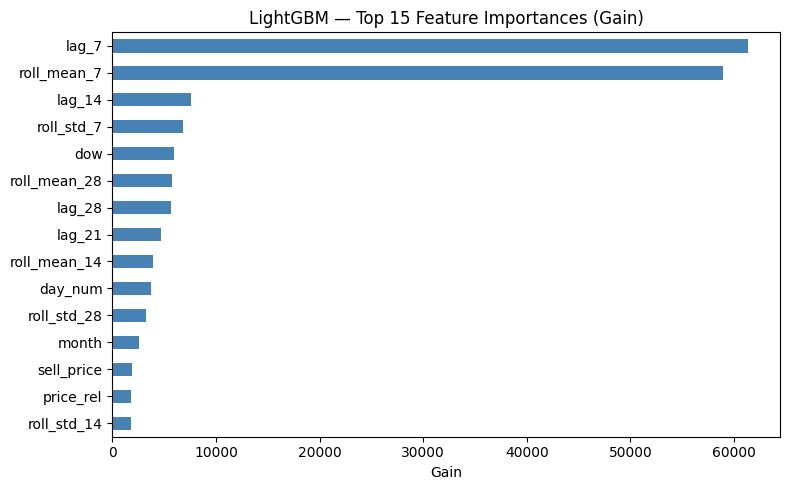


✅  LightGBM complete.


In [8]:
# ============================================================
# CELL 7 — PHASE 5a: LightGBM GLOBAL MODEL
# Tabular ML — learns cross-item patterns via lag features
# This is the most competitive approach on M5-style tasks
# ============================================================
# pip install lightgbm  (if not installed)
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

print('=' * 60)
print('PHASE 5a — LightGBM GLOBAL MODEL (Cross-Learning + Rich Features)')
print('=' * 60)

# ── 1. Build full feature table for train+val+test ────────────
def build_lgbm_features(df_all, top_items, lag_days=[7, 14, 21, 28],
                        rolling_windows=[7, 14, 28]):
    """
    Build a wide feature table.
    Critical: features are only built from history (no leakage).
    """
    df = df_all[df_all['item_id'].isin(top_items)].copy()
    df = df.sort_values(['item_id', 'day_num']).reset_index(drop=True)

    # --- Price features ---
    df['sell_price'] = df['sell_price'].astype('float32')
    df['sell_price'] = df.groupby('item_id')['sell_price'].transform(lambda x: x.ffill().bfill())
    df['price_rel']  = df.groupby('item_id')['sell_price'].transform(lambda x: x / (x.mean() + 1e-9))
    df['price_diff'] = df.groupby('item_id')['sell_price'].transform(lambda x: x.diff().fillna(0))

    # --- Calendar features ---
    df['date']      = pd.to_datetime(df['date'])
    df['dow']       = df['date'].dt.dayofweek.astype(np.int8)
    df['month']     = df['date'].dt.month.astype(np.int8)
    df['is_weekend']= (df['dow'] >= 5).astype(np.int8)
    df['dow_sin']   = np.sin(2*np.pi*df['dow']/7).astype('float32')
    df['dow_cos']   = np.cos(2*np.pi*df['dow']/7).astype('float32')
    df['month_sin'] = np.sin(2*np.pi*df['month']/12).astype('float32')
    df['month_cos'] = np.cos(2*np.pi*df['month']/12).astype('float32')
    df['event_flag']= df['event_name_1'].notna().astype(np.int8)
    type_map = {'Sporting': 1, 'National': 2, 'Cultural': 3, 'Religious': 4}
    if 'event_type_1' in df.columns:
        df['event_type_enc'] = df['event_type_1'].map(type_map).fillna(0).astype(np.int8)
    else:
        df['event_type_enc'] = 0

    # --- Lag features (sales at t-k) ---
    for lag in lag_days:
        df[f'lag_{lag}'] = df.groupby('item_id')['sales'].transform(lambda x: x.shift(lag))

    # --- Rolling statistics (mean, std) ---
    for w in rolling_windows:
        df[f'roll_mean_{w}'] = df.groupby('item_id')['sales'].transform(
            lambda x: x.shift(7).rolling(w, min_periods=1).mean())
        df[f'roll_std_{w}']  = df.groupby('item_id')['sales'].transform(
            lambda x: x.shift(7).rolling(w, min_periods=1).std().fillna(0))

    # --- Item encoding ---
    le = LabelEncoder()
    df['item_enc'] = le.fit_transform(df['item_id']).astype(np.int8)

    feature_cols = (
        ['snap_CA', 'event_flag', 'event_type_enc',
         'sell_price', 'price_rel', 'price_diff',
         'dow', 'month', 'is_weekend',
         'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
         'item_enc', 'day_num'] +
        [f'lag_{lag}' for lag in lag_days] +
        [f'roll_mean_{w}' for w in rolling_windows] +
        [f'roll_std_{w}'  for w in rolling_windows]
    )
    return df, feature_cols


# Build features on train+val+test together (lag features need history)
df_all = pd.concat([train, val, test], ignore_index=True)
df_feat, FEAT_COLS = build_lgbm_features(df_all, top_10_items)

# ── 2. Train / Val split from feature table ──────────────────
df_feat_tr  = df_feat[df_feat['day_num'] <= TRAIN_END].dropna(subset=FEAT_COLS)
df_feat_val = df_feat[(df_feat['day_num'] >= VAL_START) & (df_feat['day_num'] <= VAL_END)].dropna(subset=FEAT_COLS)
df_feat_te  = df_feat[(df_feat['day_num'] >= TEST_START)].dropna(subset=FEAT_COLS)

X_tr, y_tr   = df_feat_tr[FEAT_COLS], df_feat_tr['sales']
X_val_lgb, y_val_lgb = df_feat_val[FEAT_COLS], df_feat_val['sales']
X_te         = df_feat_te[FEAT_COLS]

print(f'  Train rows: {len(X_tr):,}   Val rows: {len(X_val_lgb):,}   Features: {len(FEAT_COLS)}')

# ── 3. Train LightGBM with early stopping ────────────────────
lgb_train = lgb.Dataset(X_tr, label=y_tr, free_raw_data=False)
lgb_val   = lgb.Dataset(X_val_lgb, label=y_val_lgb, reference=lgb_train, free_raw_data=False)

lgb_params = {
    'objective':       'regression_l1',   # MAE loss — robust to outliers
    'metric':          ['rmse', 'mae'],
    'num_leaves':      63,
    'learning_rate':   0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':    5,
    'min_child_samples': 20,
    'lambda_l1':       0.1,
    'lambda_l2':       0.1,
    'verbose':         -1,
    'seed':            SEED,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=50)
]

print('  Training LightGBM (global model, all 10 items)...')
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=callbacks,
)

# ── 4. Predict & evaluate ─────────────────────────────────────
df_feat_val['pred_lgbm'] = np.clip(lgb_model.predict(X_val_lgb), 0, None)

results_val = results_val.merge(
    df_feat_val[['item_id', 'day_num', 'pred_lgbm']],
    on=['item_id', 'day_num'], how='left'
)

print('\n  Model                                     RMSE         MAE')
print('  ' + '-'*58)
calculate_metrics(results_val['y_true'], results_val['pred_lgbm'], 'LightGBM (Global, Lag+Rolling)', metrics_val)

# Feature importance plot
imp = pd.Series(lgb_model.feature_importance(importance_type='gain'), index=FEAT_COLS).nlargest(15)
fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('LightGBM — Top 15 Feature Importances (Gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

print('\n✅  LightGBM complete.')

In [9]:
# ============================================================
# CELL 8 — PHASE 5b: LSTM GLOBAL MODEL (PyTorch)
# Global cross-learning: all 10 series trained jointly
# ============================================================
# pip install torch  (CPU version is fine for this scale)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

print('=' * 60)
print('PHASE 5b — LSTM GLOBAL MODEL (PyTorch)')
print('=' * 60)

# ── 1. Pivot to (days × items) matrix ────────────────────────
pivot_tr = train.pivot(index='day_num', columns='item_id', values='sales').fillna(0)
pivot_tr = pivot_tr[top_10_items]   # consistent column order

# SNAP for all train days (same for all items)
snap_tr  = train.drop_duplicates('day_num').set_index('day_num')['snap_CA'].reindex(pivot_tr.index).fillna(0).values
dow_tr   = train.drop_duplicates('day_num').set_index('day_num')['date'].reindex(pivot_tr.index)
dow_tr   = pd.to_datetime(dow_tr).dt.dayofweek.values

# Combine: sales (10 cols) + snap (1) + dow_sin + dow_cos = 13 features
dow_sin_tr = np.sin(2*np.pi*dow_tr/7)
dow_cos_tr = np.cos(2*np.pi*dow_tr/7)

# ── 2. Scale ──────────────────────────────────────────────────
scaler_sales = MinMaxScaler()
sales_scaled = scaler_sales.fit_transform(pivot_tr.values)

# Stack all features
extra = np.stack([snap_tr, dow_sin_tr, dow_cos_tr], axis=1)  # (T, 3)
data_arr = np.hstack([sales_scaled, extra]).astype(np.float32)  # (T, 13)

N_ITEMS  = len(top_10_items)
N_FEATS  = data_arr.shape[1]
WIN      = 56   # look-back window (8 weeks)
N_STEPS  = 28

# ── 3. Build sliding-window dataset ──────────────────────────
Xs, Ys = [], []
for i in range(WIN, len(data_arr) - N_STEPS + 1):
    Xs.append(data_arr[i - WIN : i])           # (WIN, N_FEATS)
    Ys.append(sales_scaled[i : i + N_STEPS])   # (N_STEPS, N_ITEMS)

Xs = np.array(Xs, dtype=np.float32)  # (samples, WIN, N_FEATS)
Ys = np.array(Ys, dtype=np.float32)  # (samples, N_STEPS, N_ITEMS)

dataset  = TensorDataset(torch.from_numpy(Xs), torch.from_numpy(Ys))
loader   = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)
print(f'  Tensor X: {Xs.shape}   Tensor Y: {Ys.shape}')

# ── 4. Model architecture ─────────────────────────────────────
class GlobalLSTM(nn.Module):
    def __init__(self, n_feats, n_items, hidden=128, n_layers=2, dropout=0.2, horizon=28):
        super().__init__()
        self.horizon = horizon
        self.n_items = n_items
        self.lstm = nn.LSTM(n_feats, hidden, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, horizon * n_items)
        )

    def forward(self, x):
        out, _ = self.lstm(x)             # (B, T, hidden)
        last   = out[:, -1, :]            # (B, hidden)
        pred   = self.head(last)          # (B, horizon*n_items)
        return pred.view(-1, self.horizon, self.n_items)

model_lstm = GlobalLSTM(N_FEATS, N_ITEMS, hidden=128, n_layers=2, horizon=N_STEPS).to(DEVICE)
optimiser  = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion  = nn.HuberLoss()   # robust to outliers (0-demand spikes)

# ── 5. Training loop ─────────────────────────────────────────
EPOCHS = 40
print(f'  Training {EPOCHS} epochs ...')
losses = []
for ep in range(1, EPOCHS + 1):
    model_lstm.train()
    ep_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        pred = model_lstm(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimiser.step()
        ep_loss += loss.item()
    avg = ep_loss / len(loader)
    losses.append(avg)
    if ep % 10 == 0:
        print(f'    Epoch {ep:3d}/{EPOCHS}  Loss={avg:.6f}')

# ── 6. Inference ─────────────────────────────────────────────
model_lstm.eval()
with torch.no_grad():
    # Input window: last WIN days of training
    x_inf = torch.from_numpy(data_arr[-WIN:]).unsqueeze(0).to(DEVICE)  # (1, WIN, N_FEATS)
    pred_scaled = model_lstm(x_inf).squeeze(0).cpu().numpy()            # (28, N_ITEMS)

# Inverse-scale (only the first N_ITEMS cols)
pred_sales = scaler_sales.inverse_transform(pred_scaled)  # (28, N_ITEMS)
pred_sales = np.clip(pred_sales, 0, None)

# ── 7. Attach to results ──────────────────────────────────────
lstm_rows = []
for j, item in enumerate(top_10_items):
    for k, day in enumerate(range(VAL_START, VAL_END + 1)):
        lstm_rows.append({'item_id': item, 'day_num': day, 'pred_lstm': pred_sales[k, j]})
df_lstm = pd.DataFrame(lstm_rows)
results_val = results_val.merge(df_lstm, on=['item_id', 'day_num'], how='left')

print('\n  Model                                     RMSE         MAE')
print('  ' + '-'*58)
calculate_metrics(results_val['y_true'], results_val['pred_lstm'], 'LSTM Global (PyTorch, win=56)', metrics_val)
print('\n✅  LSTM complete.')

Using device: cuda
PHASE 5b — LSTM GLOBAL MODEL (PyTorch)
  Tensor X: (1802, 56, 13)   Tensor Y: (1802, 28, 10)
  Training 40 epochs ...
    Epoch  10/40  Loss=0.006058
    Epoch  20/40  Loss=0.005192
    Epoch  30/40  Loss=0.004758
    Epoch  40/40  Loss=0.004263

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  LSTM Global (PyTorch, win=56)             RMSE=12.9618   MAE= 8.2862

✅  LSTM complete.


PHASE 6 — MODEL TOURNAMENT: VALIDATION LEADERBOARD

  VALIDATION SET (28 days):
                            Model    RMSE     MAE
1   LSTM Global (PyTorch, win=56) 12.9618  8.2862
2  LightGBM (Global, Lag+Rolling) 13.0259  8.1756
3         SARIMA (1,1,1)(1,1,1,7) 13.5296  8.4664
4    SARIMAX (Feature-Engineered) 13.9419  9.0868
5     Holt-Winters (Add+Add, m=7) 15.8334  9.9420
6                  Seasonal Naïve 18.5143 10.3857
7                           Naïve 29.1298 19.8750


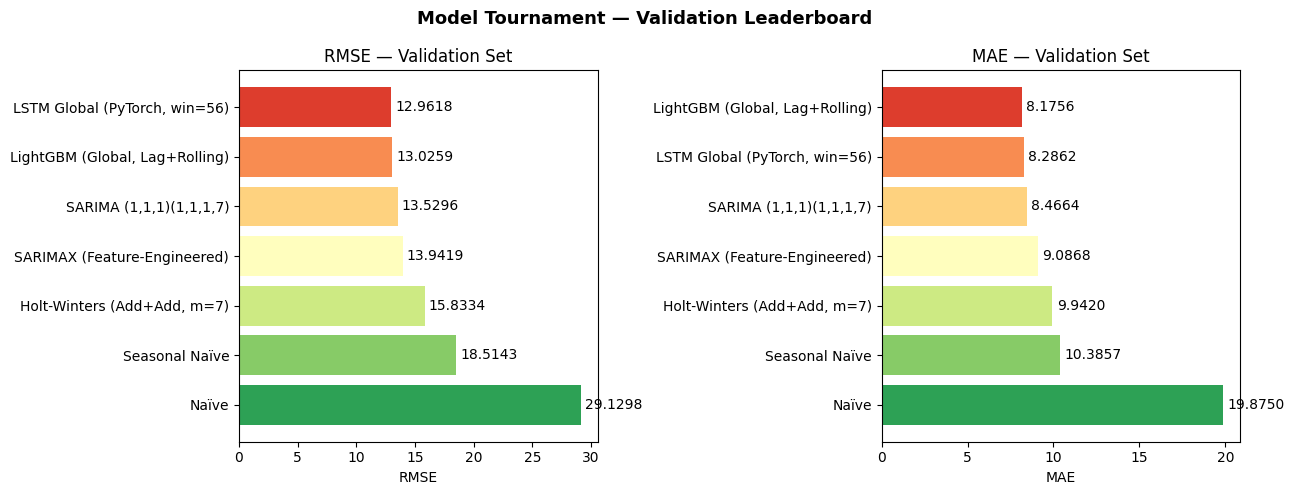

In [10]:
# ============================================================
# CELL 9 — PHASE 6a: MODEL TOURNAMENT — VALIDATION SUMMARY
# ============================================================
print('=' * 60)
print('PHASE 6 — MODEL TOURNAMENT: VALIDATION LEADERBOARD')
print('=' * 60)

# Build dataframe from stored metrics
df_leaderboard_val = pd.DataFrame(metrics_val).T.reset_index().rename(columns={'index': 'Model'})
df_leaderboard_val = df_leaderboard_val.sort_values('RMSE').reset_index(drop=True)
df_leaderboard_val.index += 1

print('\n  VALIDATION SET (28 days):')
print(df_leaderboard_val.to_string())

# ── Visual leaderboard ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette('RdYlGn_r', len(df_leaderboard_val))

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    vals = df_leaderboard_val.set_index('Model')[metric].sort_values()
    bars = ax.barh(vals.index, vals.values, color=colors[::-1])
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — Validation Set')
    ax.invert_yaxis()

plt.suptitle('Model Tournament — Validation Leaderboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CELL 10 — PHASE 6b: FINAL EVALUATION ON TEST SET (🔒 unlocked)
# ============================================================
print('=' * 60)
print('PHASE 6b — FINAL TEST SET EVALUATION (Days 1914-1941)')
print('🔒  Test set was never touched during model development.')
print('=' * 60)

# ── 1. Seasonal Naïve on test (already computed above) ───────
calculate_metrics(results_test['y_true'], results_test['pred_naive'],  'Naïve',          metrics_test)
calculate_metrics(results_test['y_true'], results_test['pred_snaive'], 'Seasonal Naïve', metrics_test)

# ── 2. Holt-Winters on test ───────────────────────────────────
from statsmodels.tsa.holtwinters import ExponentialSmoothing

preds_hw_test = []
train_val_hw  = pd.concat([train, val], ignore_index=True)
for item in top_10_items:
    y_tv = train_val_hw[train_val_hw['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)
    try:
        hw = ExponentialSmoothing(y_tv, trend='add', seasonal='add',
                                  seasonal_periods=7, initialization_method='estimated').fit(optimized=True)
        fc = np.clip(hw.forecast(28), 0, None)
    except Exception:
        hw = ExponentialSmoothing(y_tv, seasonal='add', seasonal_periods=7).fit()
        fc = np.clip(hw.forecast(28), 0, None)
    preds_hw_test.append(pd.DataFrame({'item_id': item, 'day_num': range(TEST_START, TEST_END+1), 'pred_hw': fc}))

df_hw_test = pd.concat(preds_hw_test, ignore_index=True)
results_test = results_test.merge(df_hw_test, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_hw'], 'Holt-Winters (Add+Add, m=7)', metrics_test)

# ── 3. SARIMA on test ─────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX

preds_sarima_test = []
for item in top_10_items:
    y_tv = train_val_hw[train_val_hw['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)
    mdl  = SARIMAX(y_tv, order=(1,1,1), seasonal_order=(1,1,1,7),
                   enforce_stationarity=False, enforce_invertibility=False)
    fit  = mdl.fit(disp=False)
    fc   = np.clip(fit.forecast(28), 0, None)
    preds_sarima_test.append(pd.DataFrame({'item_id': item, 'day_num': range(TEST_START, TEST_END+1), 'pred_sarima': fc}))

df_sarima_test = pd.concat(preds_sarima_test, ignore_index=True)
results_test = results_test.merge(df_sarima_test, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_sarima'], 'SARIMA (1,1,1)(1,1,1,7)', metrics_test)

# ── 4. SARIMAX on test ────────────────────────────────────────
# Retrain on train+val, forecast test.
# build_exog uses ITEM_PRICE_STATS (train-based) → consistent with val phase.
train_val_sarimax = pd.concat([train, val], ignore_index=True)
preds_sarimax_test = []
for item in top_10_items:
    df_tv  = train_val_sarimax[train_val_sarimax['item_id'] == item].sort_values('day_num')
    df_te  = test[test['item_id'] == item].sort_values('day_num')
    y_tv   = df_tv['sales'].values.astype(float)
    X_tv   = build_exog(df_tv, item_id=item)   # train-based normalisation
    X_te_  = build_exog(df_te, item_id=item)   # same train-based normalisation
    mdl    = SARIMAX(y_tv, exog=X_tv, order=(1,1,1), seasonal_order=(1,1,1,7),
                     enforce_stationarity=False, enforce_invertibility=False)
    fit    = mdl.fit(disp=False)
    fc     = np.clip(fit.forecast(28, exog=X_te_), 0, None)
    preds_sarimax_test.append(pd.DataFrame({'item_id': item, 'day_num': range(TEST_START, TEST_END+1), 'pred_sarimax': fc}))

df_sarimax_test = pd.concat(preds_sarimax_test, ignore_index=True)
results_test = results_test.merge(df_sarimax_test, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_sarimax'], 'SARIMAX (Feature-Engineered)', metrics_test)

# ── 5. LightGBM on test ───────────────────────────────────────
df_feat_te_final = df_feat[(df_feat['day_num'] >= TEST_START)].dropna(subset=FEAT_COLS)
df_feat_te_final = df_feat_te_final[df_feat_te_final['item_id'].isin(top_10_items)]
df_feat_te_final['pred_lgbm'] = np.clip(lgb_model.predict(df_feat_te_final[FEAT_COLS]), 0, None)
results_test = results_test.merge(
    df_feat_te_final[['item_id', 'day_num', 'pred_lgbm']],
    on=['item_id', 'day_num'], how='left'
)
calculate_metrics(results_test['y_true'], results_test['pred_lgbm'], 'LightGBM (Global, Lag+Rolling)', metrics_test)

# ── 6. LSTM on test ───────────────────────────────────────────
# IMPORTANT: we MUST use the original scaler_sales (fitted on train ONLY).
# Refitting a new scaler on train+val would rescale the inputs differently
# from what the LSTM saw during training → garbage predictions.
#
# Strategy: build the input window (last WIN days before test) using
# scaler_sales.transform (not fit_transform), so the scale is identical.
pivot_tv = pd.concat([train, val]).pivot(index='day_num', columns='item_id', values='sales').fillna(0)
pivot_tv = pivot_tv[top_10_items]
snap_tv  = (pd.concat([train, val])
              .drop_duplicates('day_num')
              .set_index('day_num')['snap_CA']
              .reindex(pivot_tv.index).fillna(0).values)
dow_tv   = pd.to_datetime(
    pd.concat([train, val])
    .drop_duplicates('day_num')
    .set_index('day_num')['date']
    .reindex(pivot_tv.index)
).dt.dayofweek.values
dow_sin_tv = np.sin(2*np.pi*dow_tv/7)
dow_cos_tv = np.cos(2*np.pi*dow_tv/7)

# Use scaler_sales from Cell 8 (fitted on train only) — just transform, NO refit
sales_tv_scaled = scaler_sales.transform(pivot_tv.values)
extra_tv  = np.stack([snap_tv, dow_sin_tv, dow_cos_tv], axis=1)
data_tv   = np.hstack([sales_tv_scaled, extra_tv]).astype(np.float32)

model_lstm.eval()
with torch.no_grad():
    x_te_inf   = torch.from_numpy(data_tv[-WIN:]).unsqueeze(0).to(DEVICE)
    pred_sc_te = model_lstm(x_te_inf).squeeze(0).cpu().numpy()   # (28, N_ITEMS)

# Inverse-transform with the same train-only scaler
pred_sales_te = np.clip(scaler_sales.inverse_transform(pred_sc_te), 0, None)

lstm_rows_te = []
for j, item in enumerate(top_10_items):
    for k, day in enumerate(range(TEST_START, TEST_END + 1)):
        lstm_rows_te.append({'item_id': item, 'day_num': day, 'pred_lstm': pred_sales_te[k, j]})
df_lstm_te = pd.DataFrame(lstm_rows_te)
results_test = results_test.merge(df_lstm_te, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_lstm'], 'LSTM Global (PyTorch, win=56)', metrics_test)

print('\n✅  All models evaluated on test set.')

PHASE 6b — FINAL TEST SET EVALUATION (Days 1914-1941)
🔒  Test set was never touched during model development.
  Naïve                                     RMSE=25.5938   MAE=18.0071
  Seasonal Naïve                            RMSE=13.9249   MAE= 8.4893
  Holt-Winters (Add+Add, m=7)               RMSE= 9.1050   MAE= 5.8116
  SARIMA (1,1,1)(1,1,1,7)                   RMSE= 9.0587   MAE= 5.6668


/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/py

  SARIMAX (Feature-Engineered)              RMSE= 8.9840   MAE= 5.5587
  LightGBM (Global, Lag+Rolling)            RMSE= 9.4989   MAE= 6.2224
  LSTM Global (PyTorch, win=56)             RMSE=14.0893   MAE= 8.4951

✅  All models evaluated on test set.


FINAL MODEL TOURNAMENT — TEST SET LEADERBOARD

                             Model    RMSE     MAE  RMSE_reduction_%
1    SARIMAX (Feature-Engineered)  8.9840  5.5587           35.4800
2         SARIMA (1,1,1)(1,1,1,7)  9.0587  5.6668           34.9500
3     Holt-Winters (Add+Add, m=7)  9.1050  5.8116           34.6100
4  LightGBM (Global, Lag+Rolling)  9.4989  6.2224           31.7800
5                  Seasonal Naïve 13.9249  8.4893            0.0000
6   LSTM Global (PyTorch, win=56) 14.0893  8.4951           -1.1800
7                           Naïve 25.5938 18.0071          -83.8000


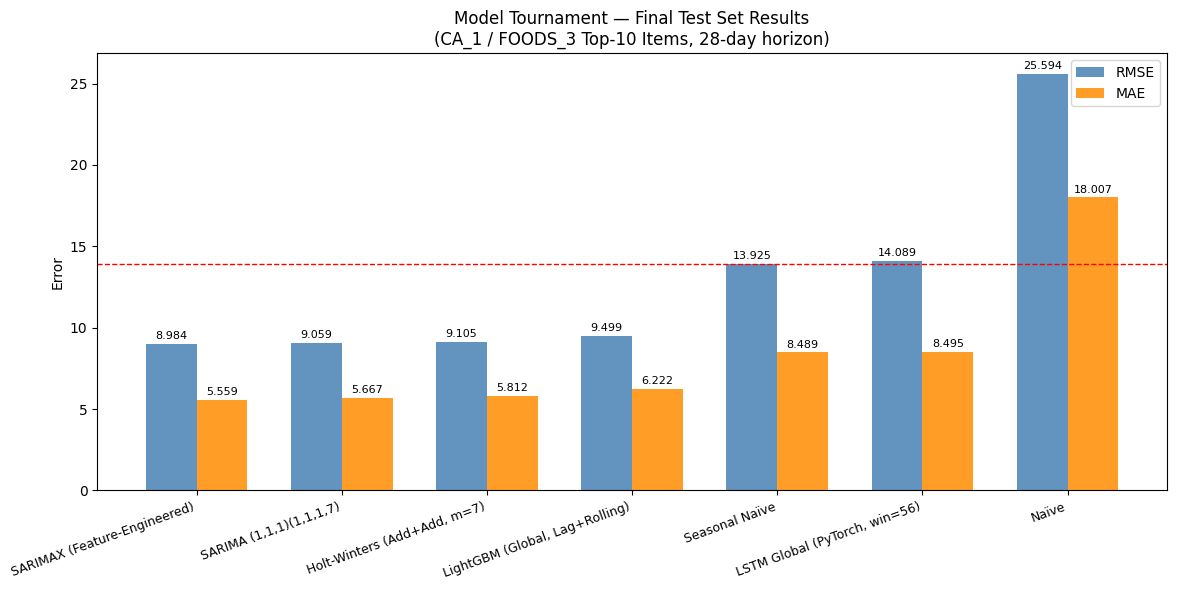


Per-item RMSE breakdown for best model: SARIMAX (Feature-Engineered)
               RMSE     MAE
item_id                    
FOODS_3_808  0.7829  0.3624
FOODS_3_541  1.0991  0.3589
FOODS_3_555  5.1320  3.5746
FOODS_3_080  5.6667  4.2349
FOODS_3_714  6.1317  5.3209
FOODS_3_586  7.3816  5.5037
FOODS_3_252  8.7875  7.0610
FOODS_3_587  9.1698  6.8051
FOODS_3_120 15.5437  9.8989
FOODS_3_090 15.8701 12.4668

✅  Model Tournament complete.


In [12]:
# ============================================================
# CELL 11 — FINAL LEADERBOARD & ANALYSIS
# ============================================================
print('=' * 60)
print('FINAL MODEL TOURNAMENT — TEST SET LEADERBOARD')
print('=' * 60)

df_final_lb = pd.DataFrame(metrics_test).T.reset_index().rename(columns={'index': 'Model'})
df_final_lb = df_final_lb.sort_values('RMSE').reset_index(drop=True)
df_final_lb.index += 1

# Compute RMSE reduction vs Seasonal Naïve baseline
baseline_rmse = df_final_lb[df_final_lb['Model'] == 'Seasonal Naïve']['RMSE'].values[0]
df_final_lb['RMSE_reduction_%'] = ((baseline_rmse - df_final_lb['RMSE']) / baseline_rmse * 100).round(2)

print('\n', df_final_lb.to_string(index=True))

# ── Grouped bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_final_lb))
w = 0.35
bars1 = ax.bar(x - w/2, df_final_lb['RMSE'], w, label='RMSE', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, df_final_lb['MAE'],  w, label='MAE',  color='darkorange', alpha=0.85)
ax.bar_label(bars1, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(bars2, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(df_final_lb['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Error')
ax.set_title('Model Tournament — Final Test Set Results\n(CA_1 / FOODS_3 Top-10 Items, 28-day horizon)', fontsize=12)
ax.legend()
ax.axhline(baseline_rmse, color='red', ls='--', lw=1, label=f'Seasonal Naïve RMSE = {baseline_rmse:.3f}')
plt.tight_layout()
plt.show()

# ── Per-item breakdown for best model ────────────────────────
best_model_col = 'pred_' + {
    'LightGBM (Global, Lag+Rolling)':  'lgbm',
    'LSTM Global (PyTorch, win=56)':    'lstm',
    'SARIMAX (Feature-Engineered)':     'sarimax',
    'SARIMA (1,1,1)(1,1,1,7)':          'sarima',
    'Holt-Winters (Add+Add, m=7)':      'hw',
    'Seasonal Naïve':                   'snaive',
    'Naïve':                            'naive',
}.get(df_final_lb.iloc[0]['Model'], 'lgbm')

print(f'\nPer-item RMSE breakdown for best model: {df_final_lb.iloc[0]["Model"]}')
per_item = (
    results_test.groupby('item_id')
    .apply(lambda g: pd.Series({
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g[best_model_col].fillna(0))),
        'MAE':  mean_absolute_error(g['y_true'], g[best_model_col].fillna(0))
    }))
    .sort_values('RMSE')
)
print(per_item.to_string())

print('\n✅  Model Tournament complete.')

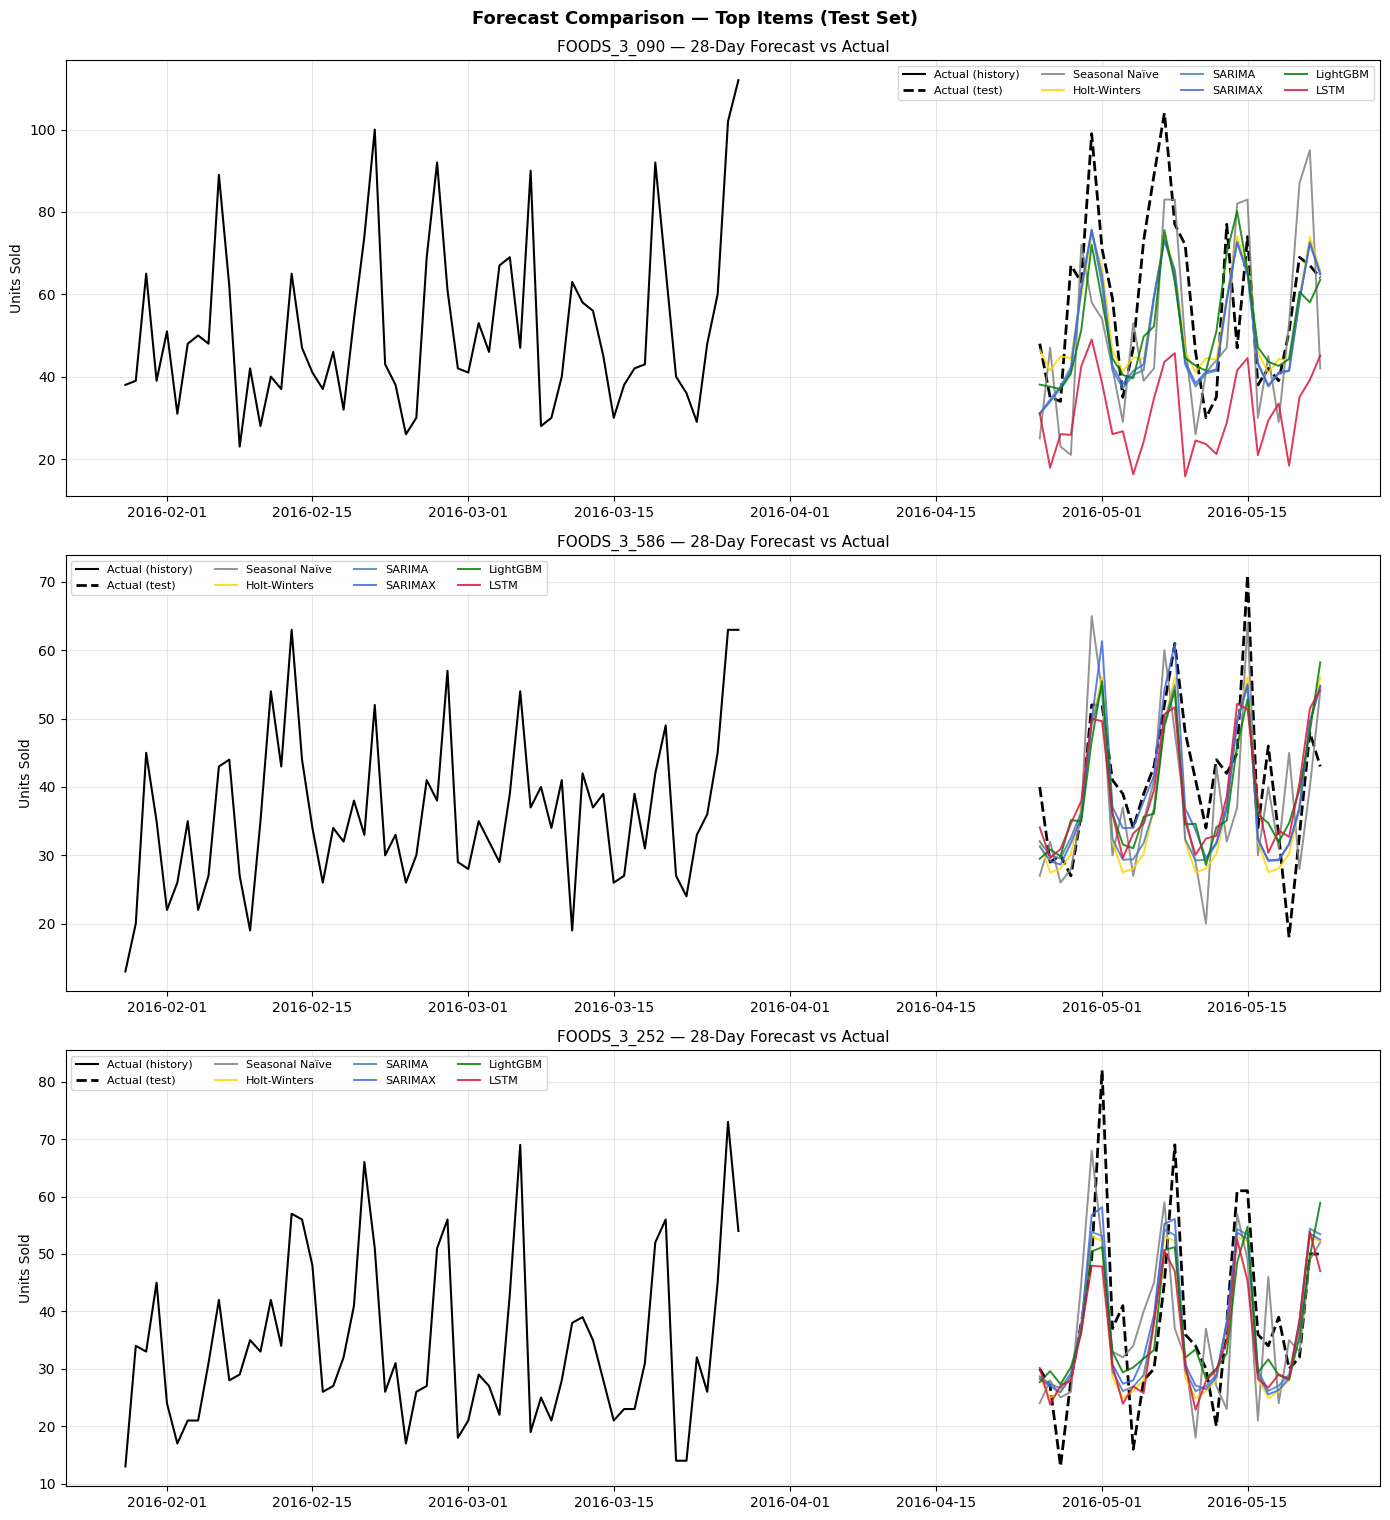

✅  Plots rendered.


In [13]:
# ============================================================
# CELL 12 — FORECAST VISUALISATION (top 3 items)
# ============================================================
n_plot = 3
items_to_plot = top_10_items[:n_plot]

pred_cols = {
    'Seasonal Naïve': 'pred_snaive',
    'Holt-Winters':   'pred_hw',
    'SARIMA':         'pred_sarima',
    'SARIMAX':        'pred_sarimax',
    'LightGBM':       'pred_lgbm',
    'LSTM':           'pred_lstm',
}
colors_map = {
    'Seasonal Naïve': 'grey',
    'Holt-Winters':   'gold',
    'SARIMA':         'steelblue',
    'SARIMAX':        'royalblue',
    'LightGBM':       'green',
    'LSTM':           'crimson',
}

fig, axes = plt.subplots(n_plot, 1, figsize=(14, 5 * n_plot), sharex=False)
if n_plot == 1: axes = [axes]

for ax, item in zip(axes, items_to_plot):
    # Context: last 60 train days
    hist = train[train['item_id'] == item].sort_values('day_num').tail(60)
    test_item = results_test[results_test['item_id'] == item].sort_values('day_num')

    # Combine for x-axis
    ax.plot(hist['date'], hist['sales'], color='black', lw=1.5, label='Actual (history)')
    ax.plot(test_item['date'], test_item['y_true'], color='black', lw=2.0, ls='--', label='Actual (test)')

    for name, col in pred_cols.items():
        if col in test_item.columns and test_item[col].notna().any():
            ax.plot(test_item['date'], test_item[col], lw=1.4,
                    color=colors_map[name], ls='-', label=name, alpha=0.85)

    ax.set_title(f'{item} — 28-Day Forecast vs Actual', fontsize=11)
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=8, ncol=4)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Forecast Comparison — Top Items (Test Set)', y=1.01, fontsize=13, fontweight='bold')
plt.show()
print('✅  Plots rendered.')